In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = { # এখানে একটি ডিকশনারি তৈরি করা হয়েছে যেখানে size (আকার) এবং তার বিপরীতে price (দাম) দেওয়া আছে।
    "size": [6,8,12,14,18],
    "price": [350,775,1150,1395,1675]
}


In [ ]:
data

{'size': [6, 8, 12, 14, 18], 'price': [350, 775, 1150, 1395, 1675]}

In [ ]:
df = pd.DataFrame(data) # ডিকশনারিটিকে একটি সুন্দর টেবিল বা ডেটাফ্রেমে রূপান্তর করা হয়েছে।
print(df)

   size  price
0     6    350
1     8    775
2    12   1150
3    14   1395
4    18   1675


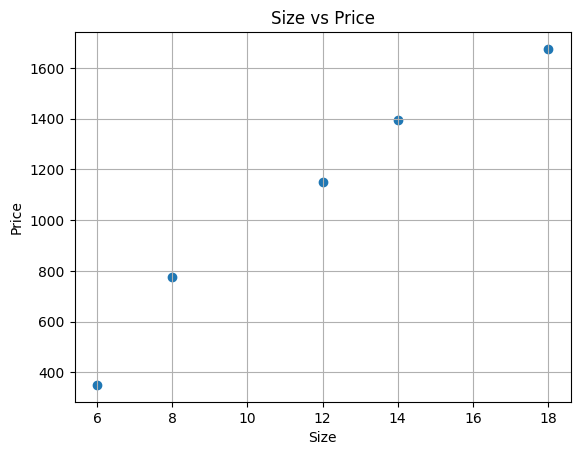

In [ ]:
plt.scatter(df['size'],data['price']) # এখানে আকার এবং দামের মধ্যে সম্পর্ক দেখানোর জন্য একটি স্ক্যাটার প্লট (বিন্দুচিত্র) আঁকা হয়েছে।
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Size vs Price')
plt.grid()
plt.show()

In [ ]:
# এই লাইনগুলো লিনিয়ার রিগ্রেশনের সূত্র প্রয়োগ করার জন্য প্রয়োজনীয় মানগুলো বের করছে।

sz_avg = df['size'].mean() # আকারের গড় (Average of size)
pr_avg = df['price'].mean() # দামের গড় (Average of price)
sz_pr = df['size']*df['price'] # আকার ও দামের গুণফল
sz_sq = df['size']*df['size'] # আকারের বর্গ (Square of size)
sz_avg_sq = sz_avg*sz_avg # আকারের গড়ের বর্গ
sz_pr_avg = sz_pr.mean() # গুণফলের গড়
sz_sq_avg = sz_sq.mean() # বর্গের গড়


In [ ]:
# ঢাল (Slope - w1) এবং ইন্টারসেপ্ট (Intercept - w0) নির্ণয়

w1 = (sz_avg*pr_avg - sz_pr_avg)/(sz_avg_sq-sz_sq_avg)
w0 = pr_avg - w1*sz_avg; # এখানে সরলরেখার সমীকরণ $y = w_1x + w_0$ এর জন্য $w_1$ (ঢাল) এবং $w_0$ (ইন্টারসেপ্ট) হিসেব করা হয়েছে।
print(w0, w1)

-174.69298245614004 107.21491228070172


In [ ]:
# প্রেডিকশন বা ভবিষ্যৎবাণী করা

x= np.array(df['size']);
y_pred = w1 * x + w0 # y_pred লাইনে আমাদের বের করা সূত্র দিয়ে প্রতিটি আকারের জন্য সম্ভাব্য দাম (Predicted Price) বের করা হয়েছে।
print(y_pred)

[ 468.59649123  683.02631579 1111.88596491 1326.31578947 1755.1754386 ]


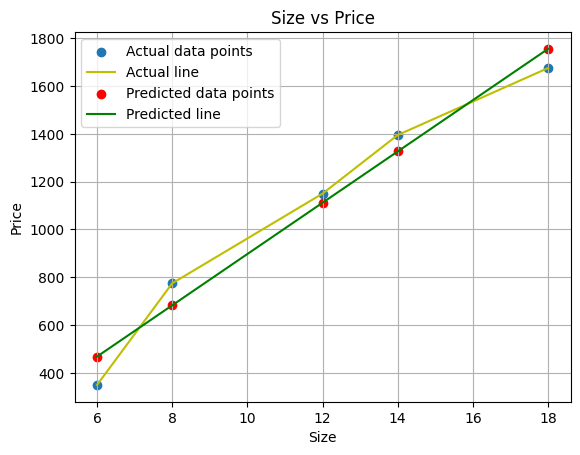

In [ ]:
plt.scatter(df['size'],data['price'],label='Actual data points') # আসল ডেটা পয়েন্ট
plt.plot(df['size'],data['price'],label='Actual line', color='y') # আসল লাইন (হলুদ)
plt.scatter(x,y_pred,color='red', label='Predicted data points') # প্রেডিক্ট করা পয়েন্ট (লাল)
plt.plot(x,y_pred,color='g', label='Predicted line') # প্রেডিক্ট করা লাইন (সবুজ)
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Size vs Price')
plt.grid()
plt.legend()
plt.show()

### R squre [Performance]

In [ ]:
up = y_pred - pr_avg # এখানে মডেলের প্রেডিক্ট করা মান (y_pred) থেকে গড় দাম (pr_avg) বিয়োগ করা হয়েছে। একে বলা হয় Explained Variation-এর অংশ।
down = df['price'] - pr_avg # এখানে আসল বা প্রকৃত দাম (price) থেকে গড় দাম বিয়োগ করা হয়েছে। এটি মোট বিচ্যুতি বা Total Variation নির্দেশ করে।
up=up**2 # বিয়োগফলগুলো পজিটিভ করার জন্য এবং বড় বিচ্যুতিগুলোকে বেশি গুরুত্ব দেওয়ার জন্য এদের বর্গ (Square) করা হয়েছে।
down=down**2 # খানে বর্গের যোগফলগুলোর অনুপাত বের করা হয়েছে।
r_sq = np.sum(up)/np.sum(down)
print(r_sq*100) #  এর মানকে ১০০ দিয়ে গুণ করে শতাংশে (Percentage) দেখানো হয়েছে।

96.75832392966129
